Epoch 10/50 - Loss: 0.8004 - Test Acc: 72.22%
Epoch 20/50 - Loss: 0.5976 - Test Acc: 77.78%
Epoch 30/50 - Loss: 0.4529 - Test Acc: 91.67%
Epoch 40/50 - Loss: 0.3327 - Test Acc: 94.44%
Epoch 50/50 - Loss: 0.2419 - Test Acc: 97.22%


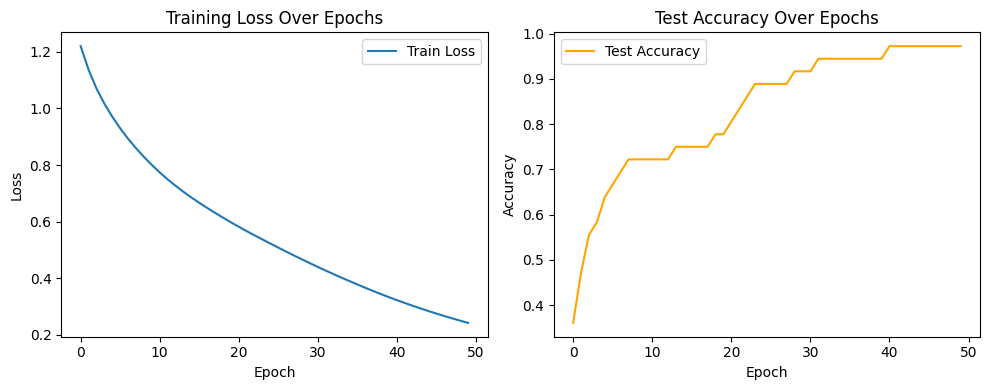


Best Predictions:
True Label: 2, Predicted: 2, Confidence: 0.9807
True Label: 2, Predicted: 2, Confidence: 0.9776
True Label: 0, Predicted: 0, Confidence: 0.9700
True Label: 2, Predicted: 2, Confidence: 0.9695
True Label: 2, Predicted: 2, Confidence: 0.9645

Worst Predictions:
True Label: 0, Predicted: 1, Confidence: 0.5314
True Label: 1, Predicted: 1, Confidence: 0.5333
True Label: 1, Predicted: 1, Confidence: 0.5705
True Label: 1, Predicted: 1, Confidence: 0.6104
True Label: 1, Predicted: 1, Confidence: 0.6807


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------
# 1. Load the Wine dataset
# ------------------------------------------------------
data = load_wine()
X = data.data         # shape: (178, 13)
y = data.target       # shape: (178,)

np.random.seed(42)

# ------------------------------------------------------
# 2. Train/test split & feature scaling
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------
# 3. One-hot encode the labels for training
# ------------------------------------------------------
num_classes = 3

def one_hot_encode(labels, num_classes):
    encoded = np.zeros((labels.size, num_classes))
    encoded[np.arange(labels.size), labels] = 1
    return encoded

y_train_onehot = one_hot_encode(y_train, num_classes)

# ------------------------------------------------------
# 4. Define MLP architecture & He Initialization
# ------------------------------------------------------
D_in = X_train.shape[1]  # 13 features
H1 = 16
H2 = 8
D_out = num_classes

# He initialization (good for ReLU)
W1 = np.random.randn(D_in, H1) * np.sqrt(2.0 / D_in)
b1 = np.zeros((1, H1))

W2 = np.random.randn(H1, H2) * np.sqrt(2.0 / H1)
b2 = np.zeros((1, H2))

W3 = np.random.randn(H2, D_out) * np.sqrt(2.0 / H2)
b3 = np.zeros((1, D_out))

# Tweaked hyperparameters:
learning_rate = 0.01  # Lowered for stability
epochs = 50  # Increased for better convergence
batch_size = 16

# ------------------------------------------------------
# 5. Helper functions (forward pass, loss, backprop)
# ------------------------------------------------------
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z_max = np.max(Z, axis=1, keepdims=True)
    exps = np.exp(Z - Z_max)
    return exps / np.sum(exps, axis=1, keepdims=True)

def forward_pass(X, W1, b1, W2, b2, W3, b3):
    hidden1 = X.dot(W1) + b1           # (N, H1)
    relu1 = relu(hidden1)
    hidden2 = relu1.dot(W2) + b2       # (N, H2)
    relu2 = relu(hidden2)
    logits = relu2.dot(W3) + b3        # (N, D_out)
    probs = softmax(logits)
    return hidden1, relu1, hidden2, relu2, logits, probs

def cross_entropy_loss(probs, y_onehot):
    N = probs.shape[0]
    correct_logprobs = -np.log(probs[np.arange(N), np.argmax(y_onehot, axis=1)] + 1e-12)
    return np.mean(correct_logprobs)

def backward_pass(X, y_onehot, hidden1, relu1, hidden2, relu2, logits, probs, W1, W2, W3):
    N = X.shape[0]
    dlogits = (probs - y_onehot) / N  # (N, D_out)

    # Gradients for last layer (W3, b3)
    dW3 = relu2.T.dot(dlogits)         # (H2, D_out)
    db3 = np.sum(dlogits, axis=0, keepdims=True)

    # Backprop through relu2
    drelu2 = dlogits.dot(W3.T)         # (N, H2)
    drelu2[relu2 <= 0] = 0

    # Gradients for layer 2 (W2, b2)
    dW2 = relu1.T.dot(drelu2)          # (H1, H2)
    db2 = np.sum(drelu2, axis=0, keepdims=True)

    # Backprop through relu1
    drelu1 = drelu2.dot(W2.T)          # (N, H1)
    drelu1[relu1 <= 0] = 0

    # Gradients for layer 1 (W1, b1)
    dW1 = X.T.dot(drelu1)              # (D_in, H1)
    db1 = np.sum(drelu1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

# ------------------------------------------------------
# 6. Mini-batch training loop
# ------------------------------------------------------
N_train = X_train.shape[0]

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    # Shuffle training data
    perm = np.random.permutation(N_train)
    X_train_shuffled = X_train[perm]
    y_train_onehot_shuffled = y_train_onehot[perm]

    for start in range(0, N_train, batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_onehot_shuffled[start:end]

        # Forward pass
        h1, r1, h2, r2, logits_batch, probs_batch = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)

        # Backward pass
        dW1, db1, dW2, db2, dW3, db3 = backward_pass(
            X_batch, y_batch, h1, r1, h2, r2, logits_batch, probs_batch, W1, W2, W3
        )

        # Parameter updates
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    # Evaluate on training and test sets every epoch
    _, _, _, _, logits_full, probs_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    loss_train = cross_entropy_loss(probs_full, y_train_onehot)
    train_losses.append(loss_train)

    _, _, _, _, logits_test, probs_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
    y_pred_test = np.argmax(probs_test, axis=1)
    acc_test = np.mean(y_pred_test == y_test)
    test_accuracies.append(acc_test)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_train:.4f} - Test Acc: {acc_test*100:.2f}%")

# ------------------------------------------------------
# 7. Plot Training Loss and Test Accuracy
# ------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs), test_accuracies, label="Test Accuracy", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 8. Display Best and Worst Predictions
# ------------------------------------------------------
probs_test_sorted = np.max(probs_test, axis=1)
best_indices = np.argsort(-probs_test_sorted)[:5]
worst_indices = np.argsort(probs_test_sorted)[:5]

print("\nBest Predictions:")
for idx in best_indices:
    print(f"True Label: {y_test[idx]}, Predicted: {y_pred_test[idx]}, Confidence: {probs_test_sorted[idx]:.4f}")

print("\nWorst Predictions:")
for idx in worst_indices:
    print(f"True Label: {y_test[idx]}, Predicted: {y_pred_test[idx]}, Confidence: {probs_test_sorted[idx]:.4f}")

# MNIST dataset

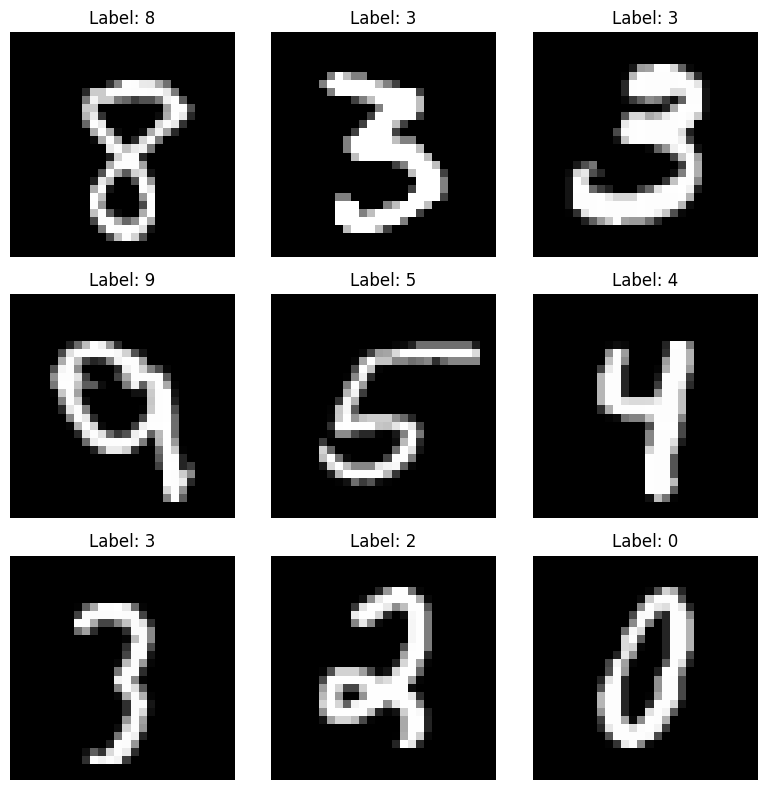

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms

# Load MNIST dataset using PyTorch
data_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=data_transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=data_transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define a function to plot some examples
def plot_mnist_examples(images, labels, num_examples=9):
    """
    Plots a grid of MNIST images with their corresponding labels.

    Parameters:
        images (torch.Tensor): Batch of image data.
        labels (torch.Tensor): Batch of labels corresponding to the images.
        num_examples (int): Number of examples to display (default is 9).
    """
    plt.figure(figsize=(8, 8))
    for i in range(num_examples):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].squeeze(0), cmap='gray')
        plt.title(f'Label: {labels[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Explanation of the MNIST dataset
"""
The MNIST dataset is a benchmark dataset in machine learning and computer vision,
consisting of 70,000 grayscale images of handwritten digits from 0 to 9.
Each image is 28x28 pixels, and the dataset is divided into a training set of 60,000 images
and a test set of 10,000 images. The goal is to classify each image into one of the 10 digit classes.

Here, we will load the MNIST dataset using PyTorch and display a few examples
from the training set to get a sense of the data.
"""

# Display some examples from the training set
examples = iter(train_loader)
example_images, example_labels = next(examples)
plot_mnist_examples(example_images[:9], example_labels[:9])


# PyTorch Example

Epoch [1/5], Loss: 0.2995
Epoch [2/5], Loss: 0.1130
Epoch [3/5], Loss: 0.0756
Epoch [4/5], Loss: 0.0592
Epoch [5/5], Loss: 0.0439


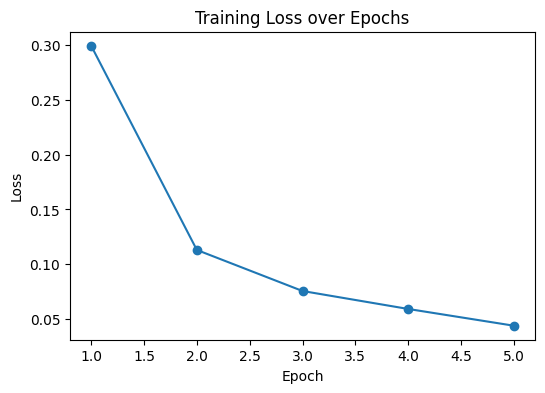

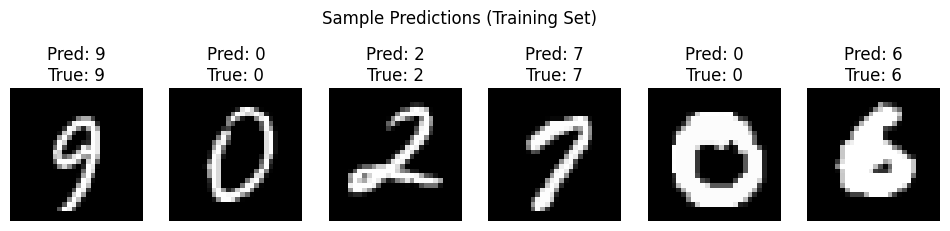


Final Test Accuracy: 97.96%


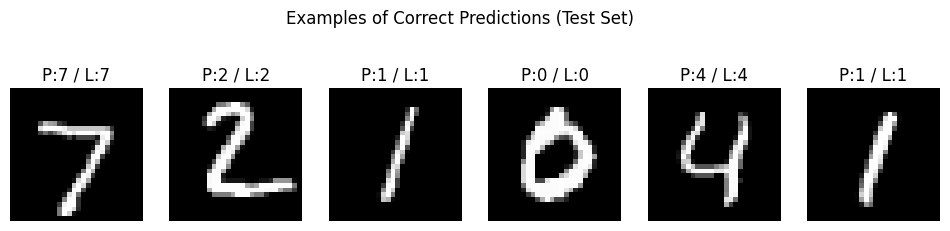

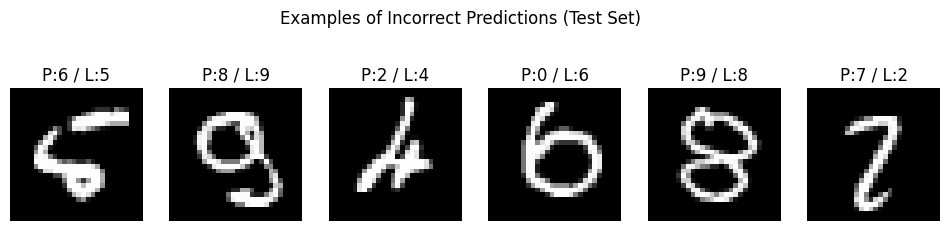

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# For inline plotting in notebooks (comment out if you're running as a .py script):
%matplotlib inline

# -----------------------------
# 1. Load the MNIST dataset
# -----------------------------
# We'll use torchvision's built-in MNIST and transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    # Optionally normalize. For MNIST, each pixel is from 0..1,
    # so normalizing isn't strictly necessary, but it's common practice.
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training data
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

# Download and load test data
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1000, shuffle=False
)

# -----------------------------
# 2. Define a simple MLP model
# -----------------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden1=128, hidden2=64, output_size=10):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)

    def forward(self, x):
        # x is [batch_size, 1, 28, 28], so flatten it
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # logits (no softmax here, see criterion)
        return x

# Instantiate the model
model = SimpleMLP()

# -----------------------------
# 3. Loss and optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()      # for multiclass classification
optimizer = optim.SGD(model.parameters(), lr=0.1)  # simple SGD

# -----------------------------
# 4. Training loop
# -----------------------------
num_epochs = 5  # for demo purposes, you can go higher (e.g. 10-20)
training_losses = []  # keep track of average loss each epoch

for epoch in range(num_epochs):
    model.train()  # set model to training mode
    running_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Clear the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backprop
        loss.backward()

        # Update parameters
        optimizer.step()

        running_loss += loss.item()

    # Compute average loss for this epoch
    avg_loss = running_loss / len(train_loader)
    training_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Plot training loss over epochs
plt.figure(figsize=(6,4))
plt.plot(range(1, num_epochs+1), training_losses, marker='o')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# -----------------------------
# 5. Show some predictions from the training set
#    (just to see how the model is doing on known data)
# -----------------------------
model.eval()
dataiter = iter(train_loader)
images, labels = next(dataiter)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Display the first 6 images in this batch
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    # Convert from (1, 28, 28) to (28, 28)
    img = images[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {predicted[i].item()}\nTrue: {labels[i].item()}")
    axes[i].axis('off')
plt.suptitle("Sample Predictions (Training Set)")
plt.show()

# -----------------------------
# 6. Evaluation on test data
# -----------------------------
model.eval()  # set model to eval mode
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        # Predictions are the indices of the max logits
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100.0 * correct / total
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")

# -----------------------------
# 7. Show correct and incorrect predictions from test set
# -----------------------------
correct_imgs = []
correct_preds = []
correct_labels = []
incorrect_imgs = []
incorrect_preds = []
incorrect_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            if predicted[i] == labels[i]:
                correct_imgs.append(images[i])
                correct_preds.append(predicted[i].item())
                correct_labels.append(labels[i].item())
            else:
                incorrect_imgs.append(images[i])
                incorrect_preds.append(predicted[i].item())
                incorrect_labels.append(labels[i].item())

# Let's display a few correct predictions
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img = correct_imgs[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"P:{correct_preds[i]} / L:{correct_labels[i]}")
    axes[i].axis('off')
plt.suptitle("Examples of Correct Predictions (Test Set)")
plt.show()

# Let's display a few incorrect predictions
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img = incorrect_imgs[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"P:{incorrect_preds[i]} / L:{incorrect_labels[i]}")
    axes[i].axis('off')
plt.suptitle("Examples of Incorrect Predictions (Test Set)")
plt.show()
